# CS235 Fall 2025 Course Project

Name: Sharmeen Kazi, Lakshmi Avasarala

Student ID: 862620019, 862620893

## Introduction
In this project, a number of data mining techniques that we cover in this class will be implemented and applied to a real-world imbalanced
dataset.

**Dataset:** Wisconsin Breast Cancer Diagnostic dataset from the UCI data repository: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

## Setup

1. Create new python environment for the project

- This is not necessary on Google Colab but a good practice on your local machine

2. Install the required packages

In [101]:
!pip install ucimlrepo

## Imports

In [83]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import itertools, collections
import numpy as np
import pandas as pd
import math

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

## Load Data

In [47]:
# Fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Metadata
print(breast_cancer_wisconsin_diagnostic.metadata)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

## Exploratory Data Analysis (EDA)

### Pairwise correlation between features

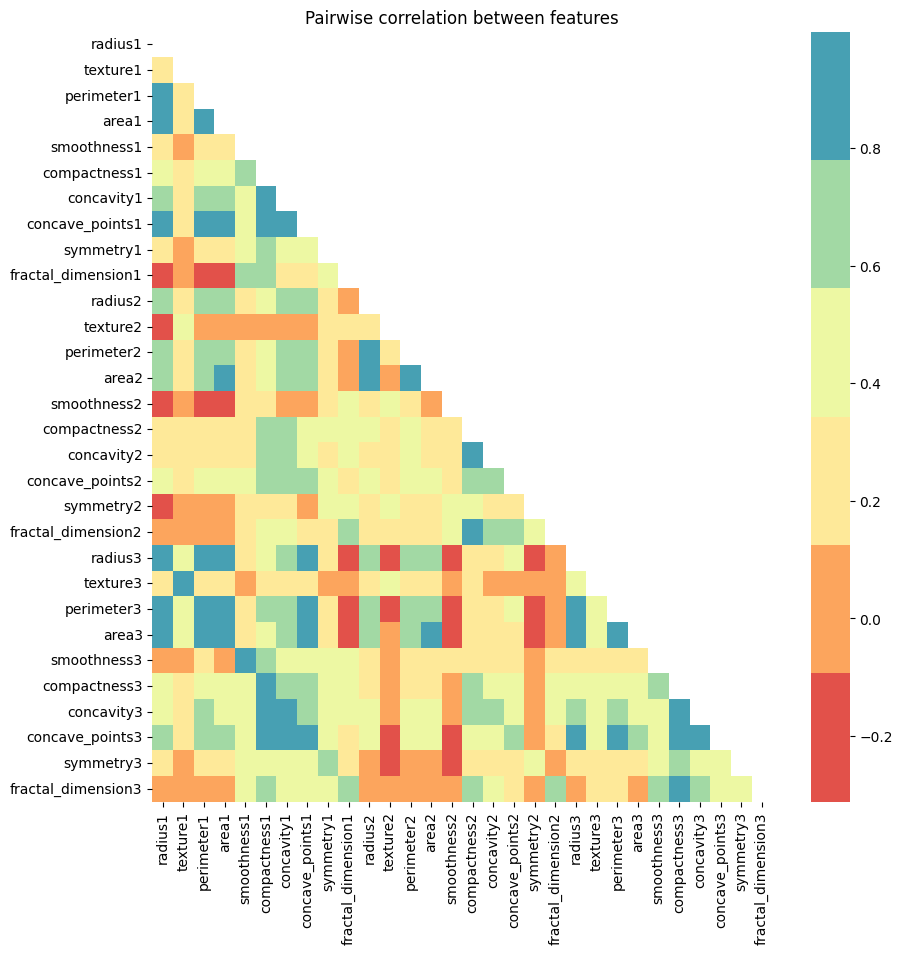

In [ ]:
correlation = X.corr()

fig, ax = plt.subplots(1,1, figsize=(10,10))
sns.heatmap(correlation, annot=False, mask=np.triu(correlation),
            cmap=sns.color_palette("Spectral"))
ax.set_title("Pairwise correlation between features")
plt.show()

### Class Counts

In [ ]:
print(collections.Counter(y['Diagnosis']))

Counter({'B': 357, 'M': 212})


### Class-wise features distributions

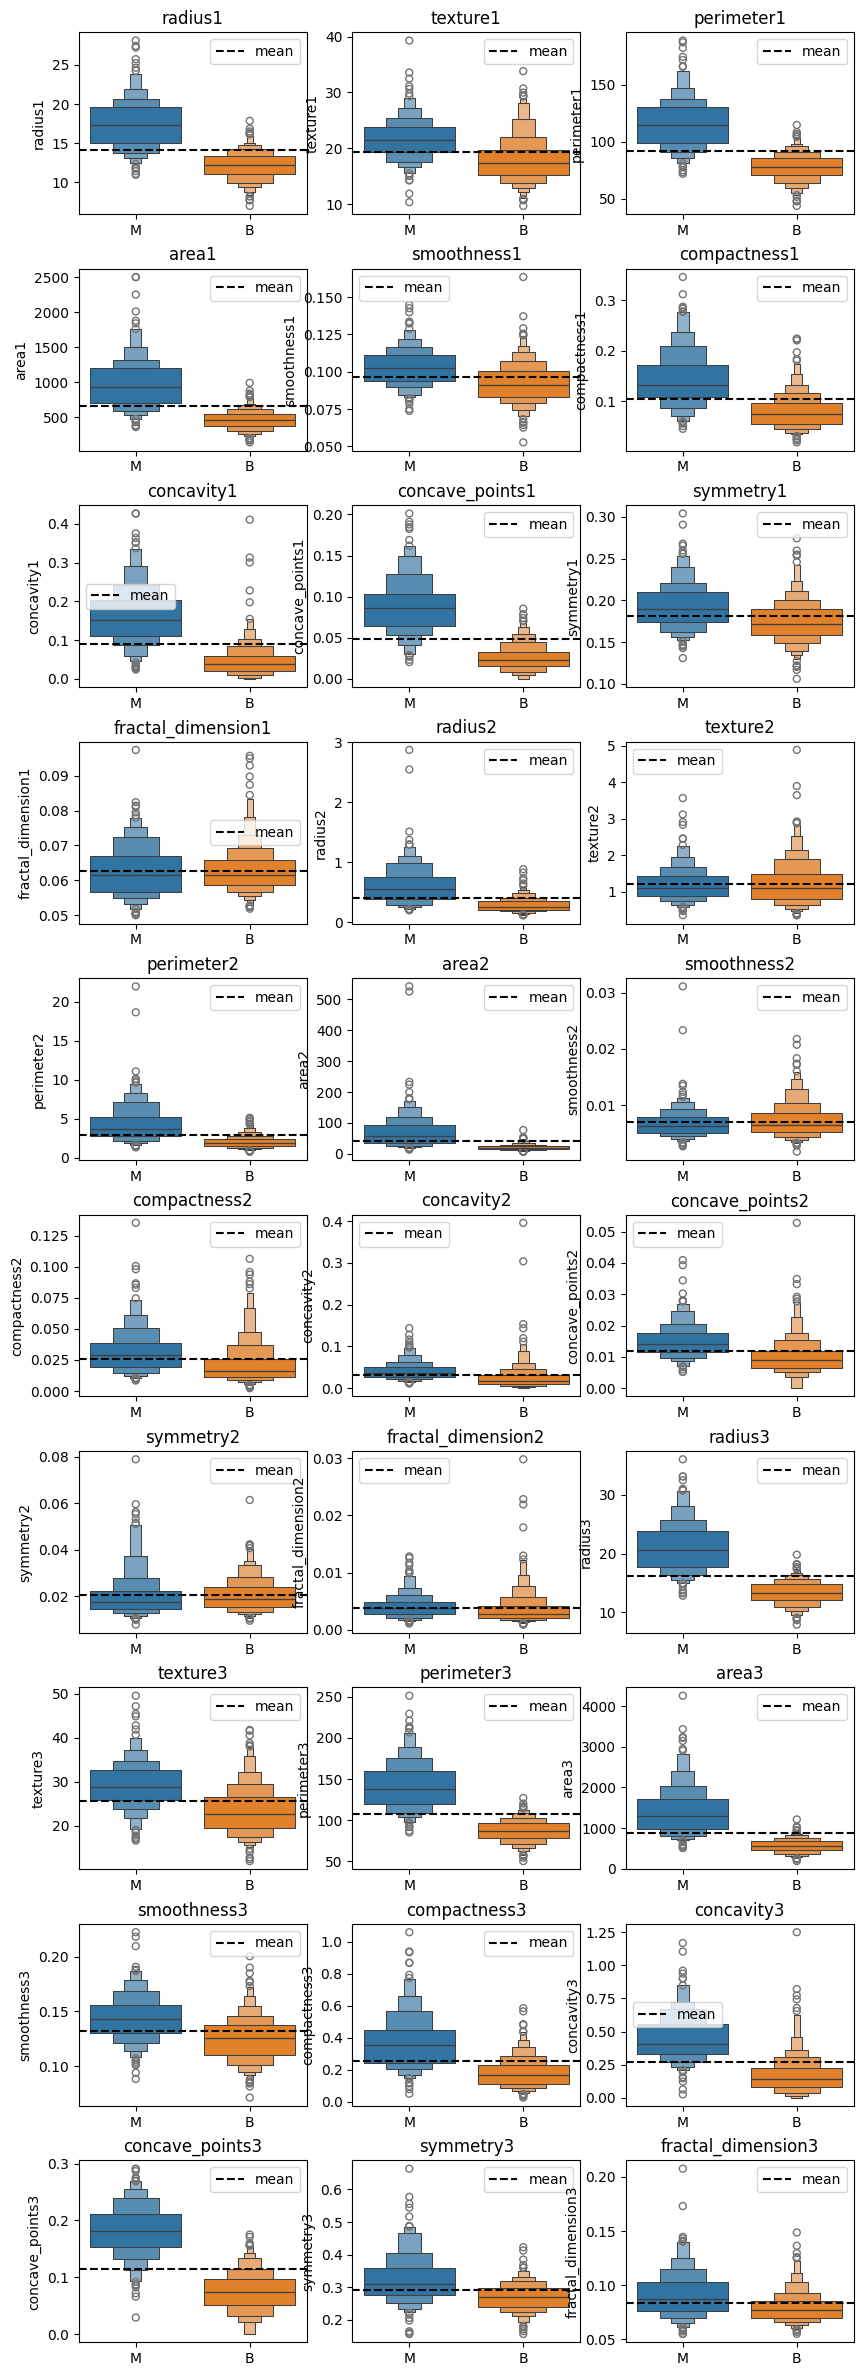

In [ ]:
plt.figure(figsize=(10,30))

for i,j in itertools.zip_longest(list(X.columns), range(len(list(X.columns)))):
  plt.subplot(10,3,j+1)
  sns.boxenplot(x=y['Diagnosis'], y=X[i], hue=y['Diagnosis'])
  plt.title(i)
  plt.xlabel('')
  plt.subplots_adjust(hspace=.3)
  plt.axhline(X[i].mean(), linestyle="dashed", color='k', label='mean')
  plt.legend(loc='best')

# Phase 1 - Supervised Techniques

## Q1 - Implementing simple classifiers

### 1. Decision Tree

We started off by creating a class for the node structure. If it is a leaf, the value will be set and others will be none. If it is a split point, the values for the feature in consideration, the threshold, the left children and the right children are set.

Then we created a class for the decision tree algorithm. We initialised the Tree with no root, a default max_depth of 5, and default minimum number of samples for splitting to 1. We implemented a function to calculate entropy as a helper for the information gain function, and then a best_split function as a helper to the build_tree function. Finally, in the fit function, we are calling the build_tree function to train the tree. For predictions we implemented the forward and predict functions that give us the predicted output of the fitted decision tree.

In [92]:
# implementation
from collections import Counter

class Node:
  def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
    self.feature_index=feature_index # index of the feature to split on
    self.threshold=threshold # threshold for the split
    self.left=left # left subtree for feature <= threshold
    self.right=right # right subtree for feature > threshold
    self.value=value # label for leaf node

class DecisionTree:
  def __init__(self, max_depth=5, min_split_samples=1):
    self.root=None # no root
    self.max_depth=max_depth # max depth
    self.min_split_samples=min_split_samples # minimum samples for split

  def entropy(self, y): # helper for information gain function
    class_counts = Counter(y) # classwise distribution
    total_count=len(y)
    entropy=0

    if total_count==0:
      return 0 # avoid dividing by 0

    for count in class_counts.values():
      p_i = count/total_count # probability of class
      entropy -= p_i * np.log2(p_i) # entropy after splitting
    return entropy

  def information_gain(self, y, y_left, y_right): # criterion for splitting
    parent_entropy = self.entropy(y)
    n = len(y)
    n_left=len(y_left)
    n_right = len(y_right)

    if n==0:
      return 0 # to avoid dividing by 0

    child_entropy = self.entropy(y_left)*(n_left/n) + self.entropy(y_right)*(n_right/n) # weighted avg
    ig = parent_entropy - child_entropy # difference is information gain
    return ig

  def best_split(self, X, y): # to find the best split
    nrows, ncols = X.shape
    if nrows < self.min_split_samples or len(np.unique(y))==1:
      return None, None # cannot split further

    max_gain = -1 # initialising training values
    best_feature_index = None
    best_threshold = None

    for feature_index in range(ncols):
      X_feature = X[:,feature_index] # extracting the feature data
      potential_thresh = np.unique(X_feature) # considering every unique value for splitting

      for thresh in potential_thresh:
        left = X_feature <= thresh # splitting to get indices
        right = X_feature > thresh
        y_left, y_right = y[left], y[right] # extracting data from split indices

        if len(y_left)==0 or len(y_right)==0:
          continue # if no splitting happened, proceed with the next feature

        gain = self.information_gain(y, y_left, y_right) # find information gain

        if gain>max_gain: # if this split is better, record it
          max_gain=gain
          best_feature_index=feature_index
          best_threshold=thresh

    return best_feature_index, best_threshold # return the recorded values

  def build_tree(self, X, y, depth=0):
    nrows, ncols = X.shape

    # termination criteria
    if (depth >= self.max_depth) or (nrows<self.min_split_samples) or (len(np.unique(y))==1):
      majority_class = Counter(y).most_common(1)[0][0] # creating a leaf node of the majority class
      return Node(value=majority_class)

    # find best split
    feature_index, thresh = self.best_split(X,y) # finds best splitting parameters

    left = X[:,feature_index] <= thresh # splitting indices
    right = X[:,feature_index] > thresh

    X_left, y_left = X[left], y[left] # splitted data extraction
    X_right, y_right = X[right], y[right]

    # building child nodes
    left_child=self.build_tree(X_left, y_left, depth+1)
    right_child = self.build_tree(X_right, y_right, depth+1)

    return Node(feature_index, thresh, left_child, right_child) # return the internal node

  def fit(self, X, y):
    X = np.asanyarray(X)
    y = np.asanyarray(y)
    self.root = self.build_tree(X,y,0) # building from the root

  def forward(self, x, node): # helper function to go through the tree
    if node.value is not None:
      return node.value # return leaf value if node is a leaf

    feature_value = x[node.feature_index]
    if feature_value <= node.threshold: # otherwose, go looking deeper
      return self.forward(x, node.left)
    else:
      return self.forward(x, node.right)

  def predict(self, X): # prediction function
    X = np.array(X)
    pred = [self.forward(x, self.root) for x in X]
    return np.array(pred)


### 2. Naive Bayes Classifier:
We implemented the Naive Bayes classifier by first determining the unique classes that y contains. We also defined a small epsilon value in the construction function to help deal with numerical instabilities later. We created empty dictionaries for the mean of each class and then populated them. By iterating through each class, we calculated their priors, and also populated the mempty mean and variance dictionaries by iterating through each feature with that class.

We defined the Gaussian distribution function as a helper for the predict function, which calculates the log of the posterior for every test sample using the gaussian likelihood function. Finally, we converted the predictions into class labels, assigning by highest log posterior.

In [93]:
class NaiveBayesClassifier:
  def __init__(self):
    self.priors = {} # to store priors of each class
    self.means = {} # to store the mean of features of each class
    self.variances = {} # to store varainceas of features in each class
    self.classes = [] # stores unique class assignments
    self.epsilon = 1e-9

  def fit(self, X, y):
    self.classes = sorted(list(set(y))) # sorted list of unique classes
    self.n_classes = len(self.classes)
    self.n_features = X.shape[1]
    N = len(X)

    self.means = {c: [0.0] * self.n_features for c in self.classes} # creating empty dictionaries of each class
    self.variances = {c: [0.0] * self.n_features for c in self.classes}

    for c in self.classes:
      X_c = X[y==c] # extracting X for that particular class
      N_c = len(X_c)

      self.priors[c] = N_c/N # calculating priors

      for j in range(self.n_features):
        feature_values = X_c[:,j] # features for each sample
        self.means[c][j] = np.mean(feature_values) # mean for each sample
        self.variances[c][j] = np.var(feature_values) + self.epsilon # variance for each sample

  def gaussian_pdf(self, x, mean, variance):
    exponent = -((x-mean)**2)/(2*variance)
    baseline = 1/math.sqrt(2*math.pi*variance) # normalization factor
    return baseline*math.exp(exponent)

  def predict(self, X):
    preds = []
    for sample in X:
      log_posteriors = {}
      for c in self.classes:
        log_posterior = math.log(max(self.priors[c], self.epsilon)) # log prior = log(P(C))
        for j in range(self.n_features): # adding log likelihoods for each feature
          likelihood = self.gaussian_pdf(sample[j], self.means[c][j], self.variances[c][j])
          log_likelihood = math.log(max(likelihood, self.epsilon))
          log_posterior += log_likelihood # accumulating by adding
        log_posteriors[c] = log_posterior
      pred_class = max(log_posteriors, key=log_posteriors.get) # prediction values
      preds.append(pred_class)
    return np.array(preds)

### 3. Measuring performance with 10-fold stratified cross-validation

We defined a performance function with 10-fold cross validation from sklearn. It iteratively splits the data into 9 training folds and 1 test fold in a stratified manner to ensure class representation persists. It fits the model passed on the training folds and evaluates on the test folds, and eventually returns the avg f1 score and its standard deviation.

Using this function, we evaluated the performance of our previously implemented classifiers, and plotted the avg f1 score and std deviation for each algorithm.

In [94]:
def performance(model, X, y):
  kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # setting up sklearn's k-fold cv object
  f1_scores = [] # to store f1_scores

  for train_index, test_index in kfold.split(X, y): # gets the training and test indices
        X_train, X_test = X[train_index], X[test_index] # splits data
        y_train, y_test = y[train_index], y[test_index]

        model.fit(X_train, y_train) # trains the model
        y_pred = model.predict(X_test) # prediction
        f1_scores.append(f1_score(y_test, y_pred, pos_label='M')) # saves f1 score, pos_label='M' specifies the positive label

  f1_mean = np.mean(f1_scores) # calculates mean
  f1_std = np.std(f1_scores) # calculates std deviation
  return f1_mean, f1_std

In [ ]:
# converting data to numpy arrays
X_np = X.to_numpy()
y_np = y.to_numpy().flatten()

In [ ]:
# initialising the two models
model1 = DecisionTree()
model2 = NaiveBayesClassifier()

results = {} # to store results

results['tree_f1_mean'], results['tree_f1_std'] = performance(model1, X_np, y_np) # performance for implemented decision tree classsifier
results['nb_f1_mean'], results['nb_f1_std'] = performance(model2, X_np, y_np) # performance for naive bayes classifier

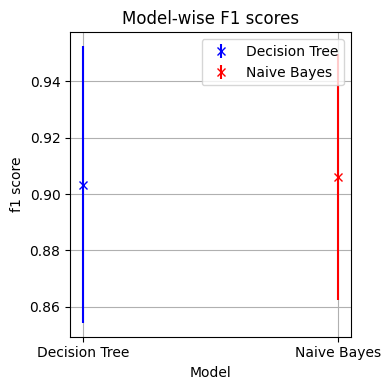

In [ ]:
# plotting mean and standard deviation of f1 score of each model
plt.figure(figsize=(4,4))

plt.errorbar('Decision Tree', results['tree_f1_mean'], yerr=results['tree_f1_std'], fmt='x', c='b', label='Decision Tree')
plt.errorbar('Naive Bayes', results['nb_f1_mean'], yerr=results['nb_f1_std'], fmt='o', c='r', label='Naive Bayes')
plt.xlabel("Model")
plt.ylabel("f1 score")
plt.title("Model-wise F1 scores")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Q2 - Dimensionality reduction with the Singular Value Decomposition

For the record, we realised too late that we could use numpy's built-in SVD function, so we used our implemented SVD function anyway.

We calculated the SVD performance through stratified K-fold cross validation for each rank upto the maximum rank. For each rank, we split the data according to the stratified folds and computed the SVD matrices for the training set. We then extracted the test set for the corresponding singular values as the training fold, with the specified rank. We fit the model on the training set of the specified rank and then evaluated its performance on the projected test set.

Finally, we plotted the f1 scores for each algorithm against their corresponding SVD ranks. We concluded that for Decision Trees, rank 9 has the highest f1 score (92%) and for Naive Bayes, rank 14 has the highest f1 score (90%)

In [ ]:
def svd(X):
    XTX = X.T @ X # calculating X^T X
    eigenvalues, V = np.linalg.eigh(XTX) # finding eigenvalues and right singular eigenvectors

    eigen_index = eigenvalues.argsort()[::-1] # findinf indices of the eigenvalues in descending order
    eigenvalues = eigenvalues[eigen_index] # sorting eigenvalues
    V = V[:, eigen_index] # reordering right-singular eigenvectors by the eigenvalues index

    singular_values = np.sqrt(eigenvalues) # calculating singular values
    singular_values[singular_values < 1e-9] = 0 # setting very small eigenvalues to zero to avoid using them in division

    U = X @ V[:, singular_values>0] @ np.diag(1/singular_values[singular_values>0]) # finding the left singular vectors

    return U, singular_values, V.T # returning the decomposed X as U, sigma, V.T

In [ ]:
def svd_performance(model, X, y, rank):
    kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # initialising 10-fold cross validation object
    f1_scores = [] # to keep track of scores

    for train_index, test_index in kfold.split(X, y): # gets the training and test indices
        X_train, X_test = X[train_index], X[test_index] # splitting data
        y_train, y_test = y[train_index], y[test_index]

        U_train, s_train, Vt_train = svd(X_train) # computing svd on the training fold

        X_train_projected = X_train @ Vt_train[:rank, :].T # extracting X_train with current rank
        X_test_projected = X_test @ Vt_train[:rank, :].T # extracting X_test with same singular values as training fold, with current rank

        model.fit(X_train_projected, y_train) # fitting the model on the projected training set for this fold
        y_pred = model.predict(X_test_projected) # predicting on the test set for this fold

        f1_scores.append(f1_score(y_test, y_pred, pos_label='M')) # calculating f1 score for this fold's test set

    return np.mean(f1_scores), np.std(f1_scores)

In [ ]:
# creating separate lists for easy plotting later
tree_f1_means = []
tree_f1_stds = []
nb_f1_means = []
nb_f1_stds = []

max_rank = min(X.shape) # rank of the whole dataset, this will be split during 10-fold cross validation

for rank in range(1, max_rank + 1): # iterating through the ranks

    # initialising models
    model1 = DecisionTree()
    model2 = NaiveBayesClassifier()

    mean, std = svd_performance(model1, X, y, rank) # performance for implemented decision tree classsifier
    tree_f1_means.append(mean) # metrics stored at index = rank-1
    tree_f1_stds.append(std)

    mean, std = svd_performance(model2, X, y, rank) # performance for naive bayes classifier
    nb_f1_means.append(mean)
    nb_f1_stds.append(std)

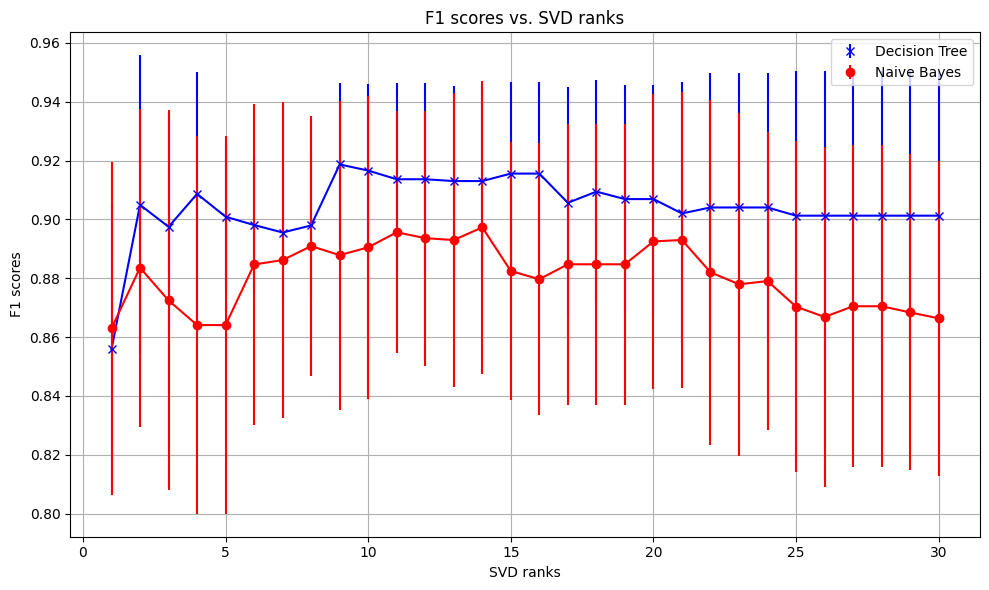

In [ ]:
# Plotting the results
plt.figure(figsize=(10, 6))

# plotting the decision tree's performance
plt.plot(range(1, max_rank + 1), tree_f1_means, c='b')
plt.errorbar(range(1, max_rank + 1), tree_f1_means, yerr=tree_f1_stds, fmt='x', c='b', label='Decision Tree')

# plotting the naive bayes classifier's performance
plt.plot(range(1, max_rank + 1), nb_f1_means, c='r')
plt.errorbar(range(1, max_rank + 1), nb_f1_means, yerr=nb_f1_stds, fmt='o', c='r', label='Naive Bayes')

plt.xlabel('SVD ranks')
plt.ylabel('F1 scores')
plt.title('F1 scores vs. SVD ranks')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Decision Tree:")
print(f"Highest mean f1 score attained: {np.max(tree_f1_means):.2f}")
print("Corresponding SVD rank:", np.argmax(tree_f1_means)+1)

print("\nNaive Bayes:")
print(f"Highest mean f1 score attained: {np.max(nb_f1_means):.2f}")
print("Corresponding SVD rank:", np.argmax(nb_f1_means)+1)

Decision Tree:
Highest mean f1 score attained: 0.92
Corresponding SVD rank: 9

Naive Bayes:
Highest mean f1 score attained: 0.90
Corresponding SVD rank: 14


## Q3 - Feature selection with randomization

We started by splitting the data into stratified 20% training and 80% test sets as mentioned. For each single feature in the dataset, we performed 5-fold cross validation on the 20% training sample. We created a copy of the original data, and then randomised the values only for the specific feature in consideration. Then, for each algorithm, we trained 2 models, one on the original data and another on the randomised data. The f1 scores of each of the 2 models for each algorithm were saved. Using these f1 scores, we calculated the importance of each feature by calculating the percentage drop in the f1 score upon randomisation.

These importance values were then plotted for each algorithm, which tells us how important the feature is, to determine the class label.

In [78]:
feature_importance_for_tree = {} # to store results
feature_importance_for_nb = {}

# splitting data into stratified 20% train and 80% test sets
X_train_cv, X_test_final, y_train_cv, y_test_final = train_test_split(X, y, test_size=0.8, stratify=y_np, shuffle=True, random_state=42)

for feature in X.columns: # train and test loop for every feature
  feature_idx = X.columns.get_loc(feature) # feature index

  # to store f1 scores
  tree_original_f1_scores = []
  tree_randomised_f1_scores = []
  nb_original_f1_scores = []
  nb_randomised_f1_scores = []

  kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5-fold cv object

  for train_index, test_index in kfold.split(X_train_cv,y_train_cv): # getting stratified indices for splitting
    # splitting the stratified 20% sample, and converting to numpy
    Xtr_original, Xts_original = X_train_cv.iloc[train_index].to_numpy(), X_train_cv.iloc[test_index].to_numpy()
    ytr, yts = y_train_cv.iloc[train_index].to_numpy().flatten(), y_train_cv.iloc[test_index].to_numpy().flatten()

    # creating copies of the original data
    Xtr_randomised = Xtr_original.copy()
    Xts_randomised = Xts_original.copy()

    # randomising the feature values
    Xtr_randomised[:, feature_idx] = np.random.permutation(Xtr_randomised[:, feature_idx])
    Xts_randomised[:, feature_idx] = np.random.permutation(Xts_randomised[:, feature_idx])

    # initiating models
    model1_original = DecisionTree()
    model2_original = NaiveBayesClassifier()

    model1_randomised = DecisionTree()
    model2_randomised = NaiveBayesClassifier()

    # training models
    model1_original.fit(Xtr_original, ytr)
    model2_original.fit(Xtr_original, ytr)

    model1_randomised.fit(Xtr_randomised, ytr)
    model2_randomised.fit(Xtr_randomised, ytr)

    # predictions and accuracy

    yhat = model1_original.predict(Xts_original) # original tree
    tree_original_f1_scores.append(f1_score(yts, yhat, pos_label='M'))

    yhat = model2_original.predict(Xts_original) # original naive bayes
    nb_original_f1_scores.append(f1_score(yts, yhat, pos_label='M'))

    yhat = model1_randomised.predict(Xts_randomised) # randomised tree
    tree_randomised_f1_scores.append(f1_score(yts, yhat, pos_label='M'))

    yhat = model2_randomised.predict(Xts_randomised) # randomised naive bayes
    nb_randomised_f1_scores.append(f1_score(yts, yhat, pos_label='M'))

  # calculating averages
  avg_tree_original_f1 = np.mean(tree_original_f1_scores)
  avg_nb_original_f1 = np.mean(nb_original_f1_scores)
  avg_tree_randomised_f1 = np.mean(tree_randomised_f1_scores)
  avg_nb_randomised_f1 = np.mean(nb_randomised_f1_scores)

  # calculating importance as percentage drop
  importance_tree = np.abs(((avg_tree_original_f1 - avg_tree_randomised_f1) / avg_tree_original_f1) * 100)
  importance_nb = np.abs(((avg_nb_original_f1 - avg_nb_randomised_f1) / avg_nb_original_f1) * 100)

  # saving importance values for each algorithm
  feature_importance_for_tree[feature] = importance_tree
  feature_importance_for_nb[feature] = importance_nb

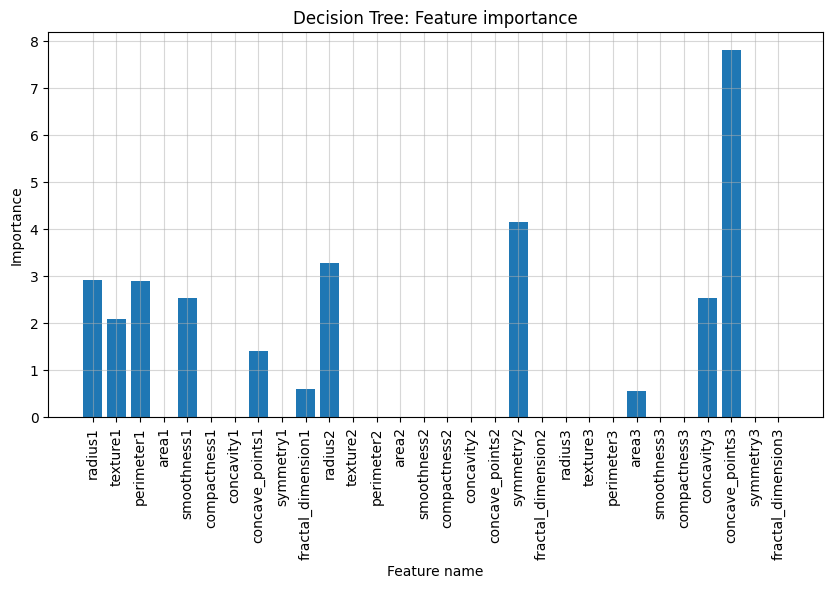

In [81]:
# plot for decision tree model
plt.figure(figsize=(10,5))
plt.bar(feature_importance_for_tree.keys(), feature_importance_for_tree.values()) # feature vs importance
plt.xticks(rotation=90)
plt.xlabel("Feature name")
plt.ylabel("Importance")
plt.title("Decision Tree: Feature importance")
plt.grid(alpha=0.5)
plt.show()

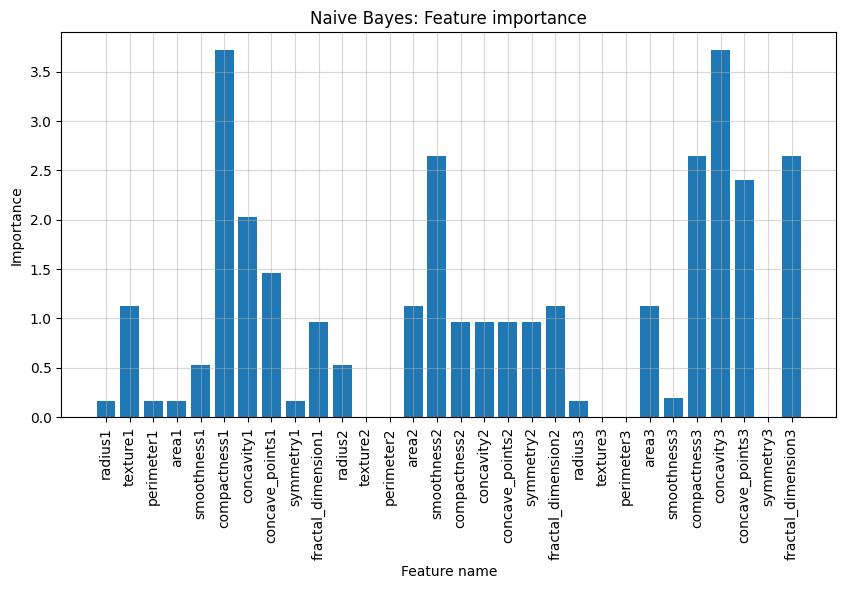

In [82]:
# plot for naive bayes classifier
plt.figure(figsize=(10,5))
plt.bar(feature_importance_for_nb.keys(), feature_importance_for_nb.values()) # feature vs importance
plt.xticks(rotation=90)
plt.xlabel("Feature name")
plt.ylabel("Importance")
plt.title("Naive Bayes: Feature importance")
plt.grid(alpha=0.5)
plt.show()

## Q4 - Data augmentation using SMOTE

We used sklearn's nearest neighbor model to find the closest k points of the point to be synthesized with. Then, we iterated through each minority sample, and calculated their k closest neighbors. For each randomly picked neighbor, we added a point by choosing a random distance ratio between the two in consideration. Finally, we returned all the synthetically generated data points.

Next, for each k = [1, 5] and oversampling percentages = 100%, 200%, and 300%, we ran the smote algorithm on the entire dataset, followed by stratified 10-fold cross validation. We used the same performance function as we created in Q1 for this.

Finally, we plotted the results for each algorithm, and each k as shown.

In [84]:
def smote(minority_X, oversampling_percentage, k=1):
    synthetic = [] # to keep track of the synthetically generated samples

    nn = NearestNeighbors(n_neighbors=k+1) # initialise sklearn nearest neighbor model, k+1 to account for the point itself
    nn.fit(minority_X) # fit the model on the minority group

    N = int(oversampling_percentage / 100) # number of synthetic samples to create for each original point

    for i in range(len(minority_X)): # iterating through each minority sample
        neighbors = nn.kneighbors([minority_X[i]], return_distance=False)[0][1:] # finds k nearest neighbors

        for j in range(N): # generating N synthetic samples
            random_neighbor = np.random.choice(neighbors) # picking a random neighbor to generate with

            diff = minority_X[random_neighbor] - minority_X[i] # distance between the two points
            ratio = np.random.random() # ratio for distance
            synthetic.append(minority_X[i] + ratio * diff) # save the synthetic sample

    return np.array(synthetic)

In [95]:
tree_results = []
nb_results = []

for k in [1, 5]:
    for N in [100, 200, 300]:
        # applying SMOTE on the full dataset since we are using the 10-fold cross validation function defined in Q1
        X_minority = X_np[y_np == 'M']
        X_majority = X_np[y_np == 'B']

        X_synthetic = smote(X_minority, N, k) # running smote

        # adding the synthetic samples to our original dataset
        X_smote = np.vstack([X_np, X_synthetic])
        y_smote = np.hstack([y_np, np.array(['M'] * len(X_synthetic))])

        # initialising models
        model1 = DecisionTree()
        model2 = NaiveBayesClassifier()

        # 10-fold cross validation
        tree_f1_mean, tree_f1_std = performance(model1, X_smote, y_smote)
        nb_f1_mean, nb_f1_std = performance(model2, X_smote, y_smote)

        # saving results
        tree_results.append({
            'k': k,
            'N': N,
            'f1_mean': tree_f1_mean,
            'f1_std': tree_f1_std
        })

        nb_results.append({
            'k': k,
            'N': N,
            'f1_mean': nb_f1_mean,
            'f1_std': nb_f1_std
        })


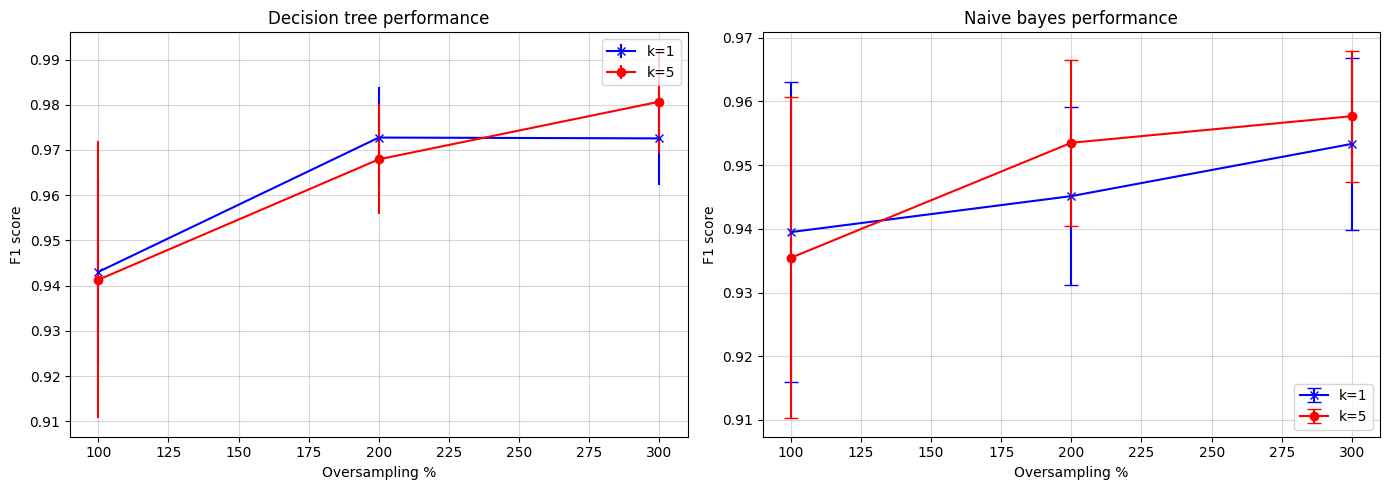

In [100]:
# converting to dataframe for easy plotting
df_tree = pd.DataFrame(tree_results)
df_nb = pd.DataFrame(nb_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # initialising the plot

# plotting the decision tree performance
data = df_tree[df_tree['k'] == 1] # extracting data for k=1
axes[0].errorbar(data['N'], data['f1_mean'], yerr=data['f1_std'], marker='x', c='b', label='k=1') # plot for k=1
data = df_tree[df_tree['k'] == 5] # extracting data for k=5
axes[0].errorbar(data['N'], data['f1_mean'], yerr=data['f1_std'], marker='o', c='r', label='k=5') # plot for k=5

axes[0].set_xlabel('Oversampling %')
axes[0].set_ylabel('F1 score')
axes[0].set_title('Decision tree performance')
axes[0].legend()
axes[0].grid(alpha=0.5)

# plotting the naive bayes classifier performance
data = df_nb[df_nb['k'] == 1] # extracting data for k=1
axes[1].errorbar(data['N'], data['f1_mean'], yerr=data['f1_std'], marker='x', c='b', label='k=1', capsize=5) # plot for k=1
data = df_nb[df_nb['k'] == 5] # extracting data for k=5
axes[1].errorbar(data['N'], data['f1_mean'], yerr=data['f1_std'], marker='o', c='r', label='k=5', capsize=5) # plot for k=5

axes[1].set_xlabel('Oversampling %')
axes[1].set_ylabel('F1 score')
axes[1].set_title('Naive bayes performance')
axes[1].legend()
axes[1].grid(alpha=0.5)

plt.tight_layout()
plt.show()